# 🧠 Introduction to CNNs for Image Classification

Until now, you've learned how to apply machine learning to structured datasets (like predicting prices or classifying data based on features). But how can we teach a machine to recognize images, like telling the difference between a **headlight**, a **bumper**, or a **wheel**?

That’s where **Convolutional Neural Networks (CNNs)** come in. CNNs are the **go-to architecture** in deep learning when it comes to visual understanding.

---

## 🧩 The Challenge with Image Data

Images are not like tabular data. A single color image of size 128×128 has **49,152 features** (128 × 128 × 3), which:
- Makes them **high-dimensional**
- Contains **spatial relationships** (e.g. a tire is round, and a headlight has glassy edges)
- Makes flattening them (as we did in ML) **lose important context**

Traditional ML methods treat all pixels independently. But CNNs understand **space** — they "look" at nearby pixels together, like how our eyes and brains work.

---

## 👁️ What is a CNN?

CNNs (Convolutional Neural Networks) are **neural networks designed specifically for images**. They learn patterns from raw pixel data through **filters** that scan the image.


![How a CNN Works](./images_gifs/cnnimage.png)


### Think of CNNs as layers of virtual eyes:
1. **Early layers** detect **edges**, **lines**, and **color patterns**
2. **Middle layers** detect **shapes**, **textures**, or **symmetry**
3. **Later layers** detect **parts**, **objects**, or **combinations**

All this happens without us manually designing the features. CNNs learn them during training.

---

![Digits](images_gifs/cnndigits.gif)

### 💡 How a CNN Works (Layer Ideas)

**Convolution Layer**
➤ Learns small visual patterns (like edges, curves, textures)
➤ Uses filters that slide over the image

**Activation (ReLU)**
➤ Keeps only useful signals (sets negatives to 0)
➤ Adds non-linearity so it can learn complex patterns

**Pooling Layer**
➤ Shrinks the feature maps (like zooming out)
➤ Keeps the strongest features (e.g., max pooling)

**More Conv + Pool Layers**
➤ Deeper layers learn higher-level parts (like car lights, tires)
➤ Each layer builds on the previous ones

**Flatten Layer**
➤ Turns 2D feature maps into a 1D vector
➤ Prepares data for the final decision

**Fully Connected (Dense) Layers**
➤ Combine all features to predict the class
➤ Similar to layers in traditional neural networks

**Softmax Output**
➤ Outputs class probabilities
➤ The highest value is the model’s prediction

![convs](images_gifs/convolutions.gif)

### Your Challenge:

In this notebook, we’ll train a CNN to recognize different **car parts** from images. These might include parts like:
- air compressor
- battery
- brake caliper
- coil spring
- oil pan and so on

**Total of 50 car parts**


You don’t need to **tell** the model what a headlight looks like — it will **learn** the patterns by itself from labeled training images.


By the end of this notebook, you'll be able to:

✅ Load and preprocess image data  
✅ Build your own CNN using TensorFlow/Keras  
✅ Train and evaluate the model  
✅ Visualize performance with graphs and confusion matrices  
✅ Experiment with changes and improve accuracy  


## 🖼️ Let's Look at Some Examples!

Before we start coding, here are some sample images from our dataset (randomly picked from different classes):

In [3]:
import os

print(os.listdir())

['.config', 'dataset.zip', 'sample_data']


In [4]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset extracted!")

Dataset extracted!


In [5]:
print(os.listdir())

['.config', 'dataset', 'dataset.zip', 'sample_data']


In [6]:
import os

print(os.path.exists("dataset/car parts.csv"))
print(os.path.exists("dataset/train"))
print(os.path.exists("dataset/valid"))
print(os.path.exists("dataset/test"))

True
True
True
True


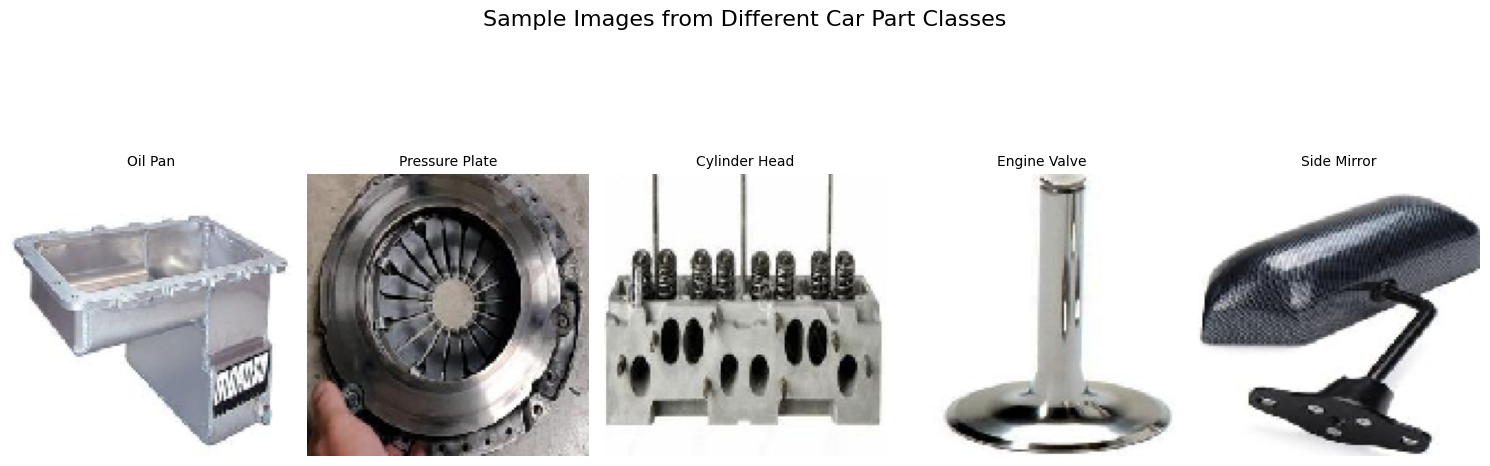

In [7]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from PIL import Image

dataset_path = './dataset/train'

class_dirs = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

sampled_classes = random.sample(class_dirs, min(5, len(class_dirs)))

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(sampled_classes):
    class_folder = os.path.join(dataset_path, class_name)

    valid_extensions = ['.jpg', '.jpeg', '.png']
    images_in_class = [f for f in os.listdir(class_folder)
                       if f.lower().endswith(tuple(valid_extensions)) and not f.startswith('.')]

    if not images_in_class:
        continue

    sample_image = random.choice(images_in_class)
    img_path = os.path.join(class_folder, sample_image)

    img = image.load_img(img_path, target_size=(128, 128))
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.title(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Different Car Part Classes", fontsize=16)
plt.tight_layout()
plt.show()


- The first thing in every classification project: we take a random image from each class and we print it.
- We resize it (img = image.load_img(img_path, target_size=(128, 128))) because the model cannot receive different image sizes.


In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/car parts.csv')
df.head(20)

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train
5,0,train/AIR COMPRESSOR/006.jpg,AIR COMPRESSOR,train
6,0,train/AIR COMPRESSOR/007.jpg,AIR COMPRESSOR,train
7,0,train/AIR COMPRESSOR/008.jpg,AIR COMPRESSOR,train
8,0,train/AIR COMPRESSOR/009.jpg,AIR COMPRESSOR,train
9,0,train/AIR COMPRESSOR/010.jpg,AIR COMPRESSOR,train


In [9]:
label_counts = df['labels'].value_counts().sort_values(ascending=False)
label_counts

,count
labels,
IGNITION COIL,210
IDLER ARM,208
STARTER,205
CARBERATOR,202
ALTERNATOR,200
OVERFLOW TANK,199
SHIFT KNOB,199
RADIO,199
FUEL INJECTOR,198


#### TODO: Research about data augmentation and what to do in case of an unbalanced dataset
##### At the end of the notebook, you can apply these techniques and train another CNN and compare results

### Your task:

#### Quick CNN Workflow for Image Classification

1. **Load & preprocess data**  
   - Resize images and normalize pixel values (e.g., scale pixels to [0,1])  
   - Prepare labels for classification  

2. **Create training and validation data generators**  
   - Use `ImageDataGenerator` or custom loaders to batch and augment data  (If you want to, or skip this part for now)

3. **Build the CNN model**  
   - Stack convolutional layers (Conv2D + activation function) and pooling layers
   - Flatten and add dense layers for final classification  
   - Make sure to use the right activation function for the last Dense layer.

4. **Compile the model**  
   - Use suitable loss function nd an optimizer like Adam  

5. **Train the model**  
   - Fit the model on training data and validate on validation data over multiple epochs  
   - Find the right number of batches/epochs for your data

6. **Evaluate and visualize results**  
   - Plot Accuracy & Loss Curves for training/validation
   - Learn about overfitting/underfitting and how to prevent these situations
   - Generate confusion matrix and classification report, based on metrics like accuracy

7. **Explore**
   - Use a pretrained available model
   - Change the architecture
   - Integrate the model into a small GUI and make it more interactive
   - Test with images from the internet, and see how well it performs


Exploring the dataset
-------------------------

In [10]:
#first, we import libraries we're gonna use in this module
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

Why are they important?

- **pandas** is used to work with tabular data.
- **NumPy** is used for numerical operations.
- **Matplotlib** is used to create charts and display images.
- **TensorFlow** is used to load image datasets and build the CNN model.

Load dataset metadata
------------

Before working with the images, we load the dataset metadata from the CSV file.

This file contains useful information about the images and their corresponding classes.

In [11]:
car_parts_df = pd.read_csv("dataset/car parts.csv")

car_parts_df.head()

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train


Before loading the images, we inspect the dataset to better understand its size and structure.

This step helps us identify the available columns and verify that the dataset has been loaded correctly.

In [12]:
print(f"Number of samples: {len(car_parts_df)}")

car_parts_df.info()

Number of samples: 9239
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9239 entries, 0 to 9238
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class index  9239 non-null   int64 
 1   filepaths    9239 non-null   object
 2   labels       9239 non-null   object
 3   data set     9239 non-null   object
dtypes: int64(1), object(3)
memory usage: 288.8+ KB


In [13]:
print("Missing values:")
print(car_parts_df.isnull().sum())

print("\nDuplicate rows:")
print(car_parts_df.duplicated().sum())

Missing values:
class index    0
filepaths      0
labels         0
data set       0
dtype: int64

Duplicate rows:
0


### Data quality

The dataset does not contain missing values or duplicate rows. Therefore, no additional data cleaning was required before building the image pipeline.

## Class distribution

Before training the CNN model, it is useful to inspect how the images are distributed across the different classes.

A class distribution plot helps identify whether the dataset is balanced or if some classes contain significantly more images than others.

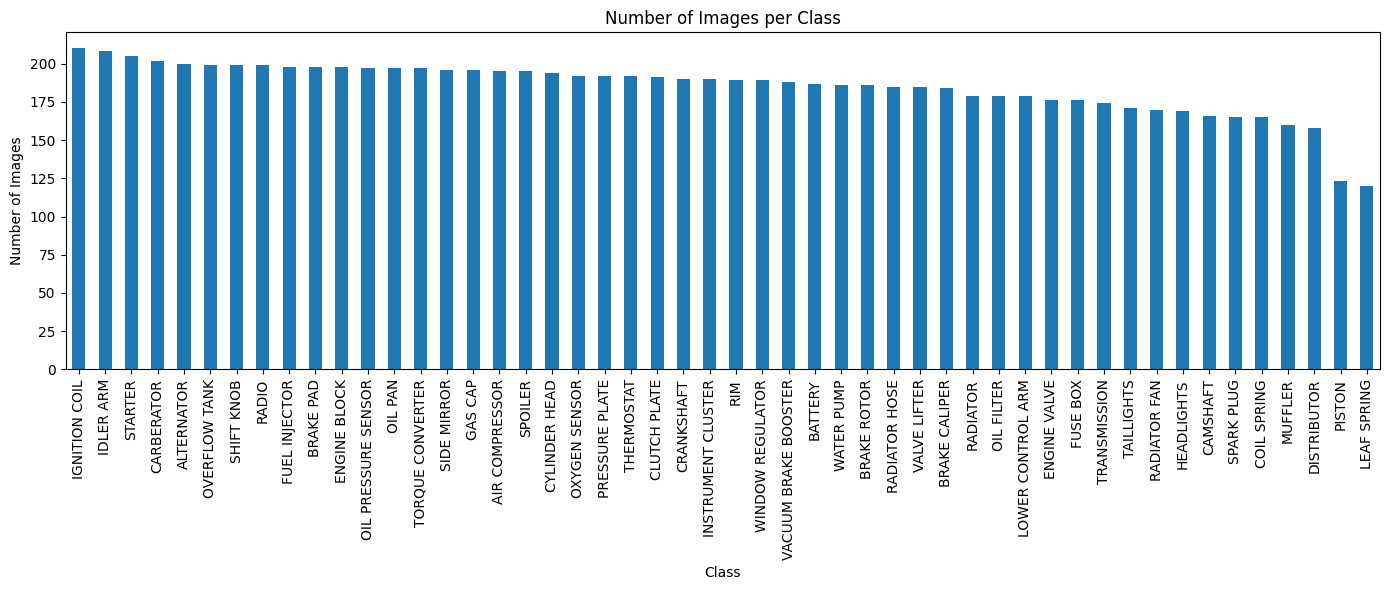

In [14]:
class_counts = car_parts_df["labels"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
class_counts.plot(kind="bar")

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Conclusion

The dataset appears to be well balanced, as most classes contain a similar number of images. This is beneficial for training a CNN because the model will have a comparable number of examples for each class.

Next, we will display a few sample images to better understand the dataset before creating the image pipeline.

In [15]:
car_parts_df.head()


,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train


## Display sample images

Before training the CNN model, it is useful to inspect a few images from the dataset.

Displaying sample images helps verify that the file paths are correct and provides a better understanding of the different car part classes.

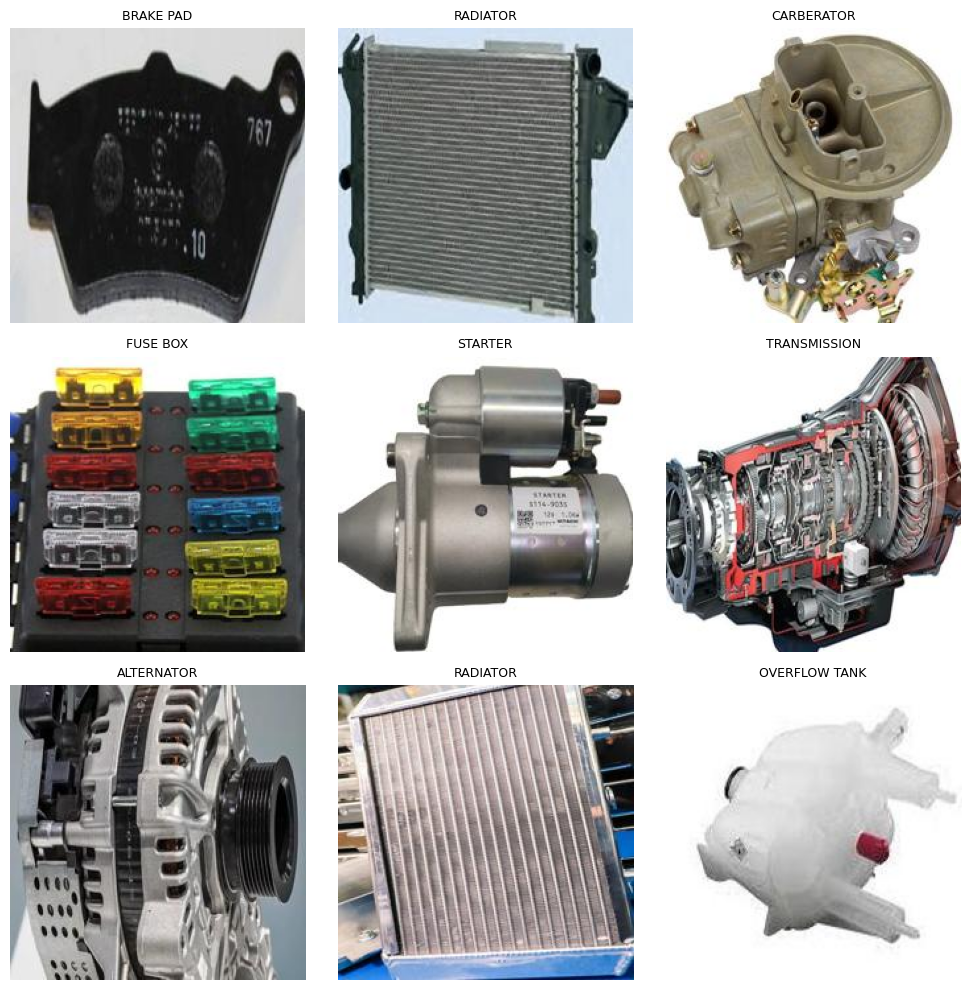

In [16]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

sample_images = car_parts_df.sample(9, random_state=42)

plt.figure(figsize=(10, 10))

for i, (_, row) in enumerate(sample_images.iterrows(), start=1):
    image_path = Path("dataset") / row["filepaths"]

    plt.subplot(3, 3, i)
    plt.imshow(Image.open(image_path))
    plt.title(row["labels"], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Conclusion

The sample images confirm that the dataset contains different categories of car parts and that the image paths are valid. The images also show variations in appearance, orientation, and background, which makes the classification task more realistic.

The next step is to create the TensorFlow data pipeline for loading, resizing, and preprocessing the images before training the CNN model.

## Create the image loading pipeline

The next step is to create an image loading pipeline for the training, validation, and test datasets.

The images are resized to a fixed size of 128 × 128 pixels and the pixel values are normalized to the range [0, 1]. The data generators also load the images in batches, making them ready for training the CNN model.

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
#image size
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

In [19]:
#create generator, I did not use augumentation, I only used rescale
image_generator = ImageDataGenerator(
    rescale=1.0 / 255
)

In [20]:
#training generator
train_generator = image_generator.flow_from_directory(
    "dataset/train",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

Found 8739 images belonging to 50 classes.


In [21]:
#validation generator
valid_generator = image_generator.flow_from_directory(
    "dataset/valid",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 250 images belonging to 50 classes.


In [22]:
#test generator
test_generator = image_generator.flow_from_directory(
    "dataset/test",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 250 images belonging to 50 classes.


### Verify the data pipeline

Before training the CNN model, it is important to verify that the image pipeline loads the data correctly.

The following step checks the batch shape and confirms that the pixel values have been normalized to the range [0, 1].

In [23]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 50)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Conclusion

The image loading pipeline was successfully created for the training, validation, and test datasets.

All images are resized to 128 × 128 pixels and their pixel values are normalized to the range [0, 1]. The batch shape confirms that each batch contains 32 RGB images and 50 class labels, making the data ready for CNN training.

# Build the CNN model

## Introduction

After preparing the image dataset, the next step is to build a Convolutional Neural Network (CNN).

A CNN learns to recognize visual patterns such as edges, shapes, and textures. These features are gradually combined to identify different car parts.

In this section, we create a simple CNN architecture for multi-class image classification.

## Import CNN layers

The following layers are used to build the CNN architecture.

In [24]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

## CNN architecture

The model is composed of three convolutional blocks.

Each block contains:

- a convolutional layer to extract image features;
- a ReLU activation function;
- a max pooling layer to reduce the image dimensions.

The extracted features are flattened and passed through fully connected layers to predict one of the 50 car part classes.

In [25]:
model = Sequential([

    Input(shape=(128, 128, 3)),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(
        units=128,
        activation="relu"
    ),

    Dense(
        units=50,
        activation="softmax"
    )

])

## Model summary

The model summary provides an overview of the CNN architecture.

It displays the layers, output shapes, and the number of trainable parameters.

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,311,090 (12.63 MB)

 Trainable params: 3,311,090 (12.63 MB)

 Non-trainable params: 0 (0.00 B)

## Conclusion

A simple CNN model has been successfully built for image classification.

The architecture includes three convolutional blocks, a flatten layer, and fully connected layers. The final Softmax layer predicts one of the 50 car part classes.

The model is now ready to be compiled and trained using the prepared image datasets.

# Compile the CNN Model

Before training, the model must be compiled.

In this step we choose:

- the loss function
- the optimizer
- the evaluation metric

Since this is a multi-class classification problem with one-hot encoded labels, we use `categorical_crossentropy`.

The Adam optimizer is chosen because it is simple and performs well for most CNN models.

Model accuracy will be used to monitor the learning process.

In [27]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the CNN Model

The model is trained using the training dataset and validated on the validation dataset.

We start with:

- batch size: 32
- epochs: 15 using the training dataset and validated on the validation dataset after each epoch.

The validation dataset allows us to monitor whether the model generalizes well to unseen data.
During training, both loss and accuracy are monitored to evaluate the learning process and detect possible overfitting.

In [28]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.1795 - loss: 3.2602 - val_accuracy: 0.3360 - val_loss: 2.5435
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.4561 - loss: 2.0525 - val_accuracy: 0.4680 - val_loss: 2.0651
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6397 - loss: 1.3160 - val_accuracy: 0.5200 - val_loss: 1.9793
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7965 - loss: 0.7038 - val_accuracy: 0.5040 - val_loss: 2.4260
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9051 - loss: 0.3342 - val_accuracy: 0.4560 - val_loss: 3.1270
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9482 - loss: 0.1699 - val_accuracy: 0.4920 - val_loss: 4.0331
Epoch 7/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9613 - loss: 0.1348 - val_accuracy: 0.4600 - val_loss: 4.2029
Epoch 8/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9673 - loss: 0.1080 - val_ac

Best validation performance was reached at epoch 3, with approximately 52% validation accuracy. Then we have to face overfitting.

# Training and Validation Loss

The loss curve shows how the error changes during training.

Comparing training loss and validation loss helps identify whether the model is learning correctly or starting to overfit.

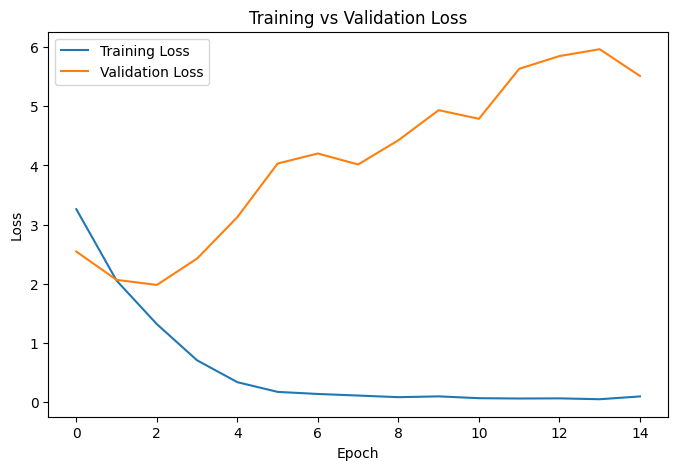

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# Training and Validation Accuracy

Accuracy measures how many predictions are correct.

Comparing training and validation accuracy helps evaluate the model's ability to generalize to new images.

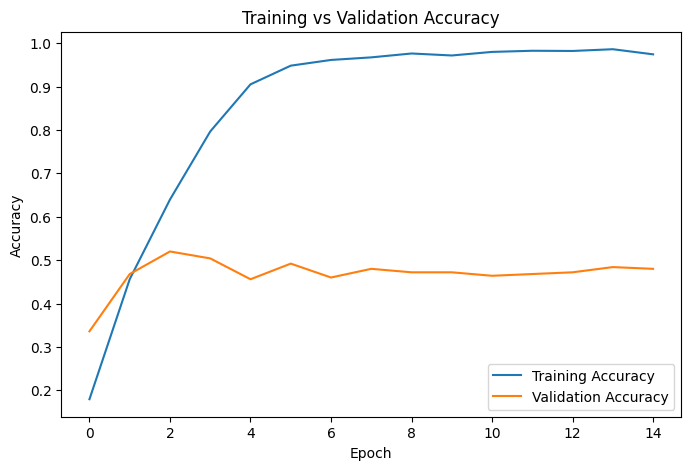

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# **Training Analysis**
The model successfully learned the training dataset.

Training accuracy increased from approximately 18% to 98%, while training loss continuously decreased.

Validation accuracy improved during the first few epochs and reached its best value of approximately 52% at epoch 3.

After that, validation accuracy stopped improving and validation loss increased significantly, indicating that the model started memorizing the training data instead of generalizing to unseen images.

Overall, the model is overfitting.

# Techniques to Prevent Overfitting

Some common techniques to reduce overfitting are:

1. **Dropout**
   - Randomly disables neurons during training.
   - Helps prevent the network from relying too much on specific features.

2. **Data Augmentation**
   - Generates new image variations using flips, rotations or zoom.
   - Increases dataset diversity.

3. **Early Stopping**
   - Stops training when validation performance stops improving.
   - Prevents unnecessary training.

Other useful techniques include:

- Batch Normalization
- L2 Regularization